In [22]:
import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import plotly.express as px

%matplotlib inline

In [23]:
df = pd.read_csv('hanoi-aqi-weather-data.csv')  


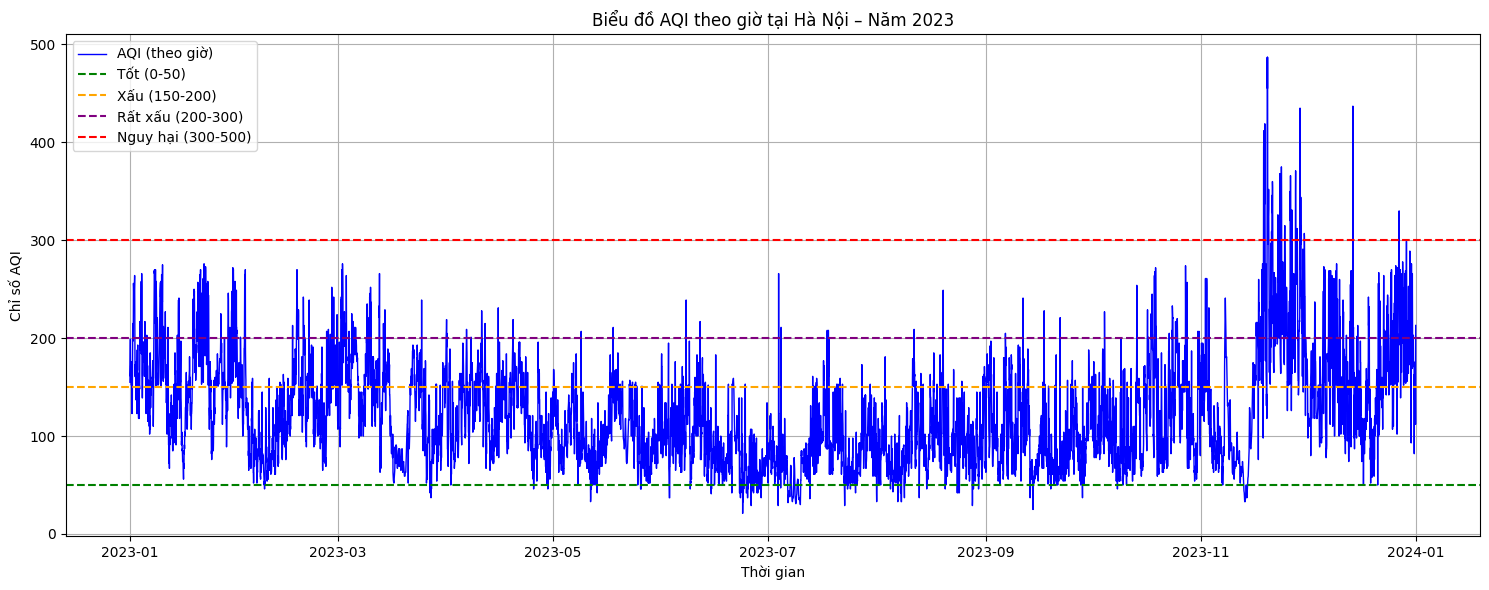

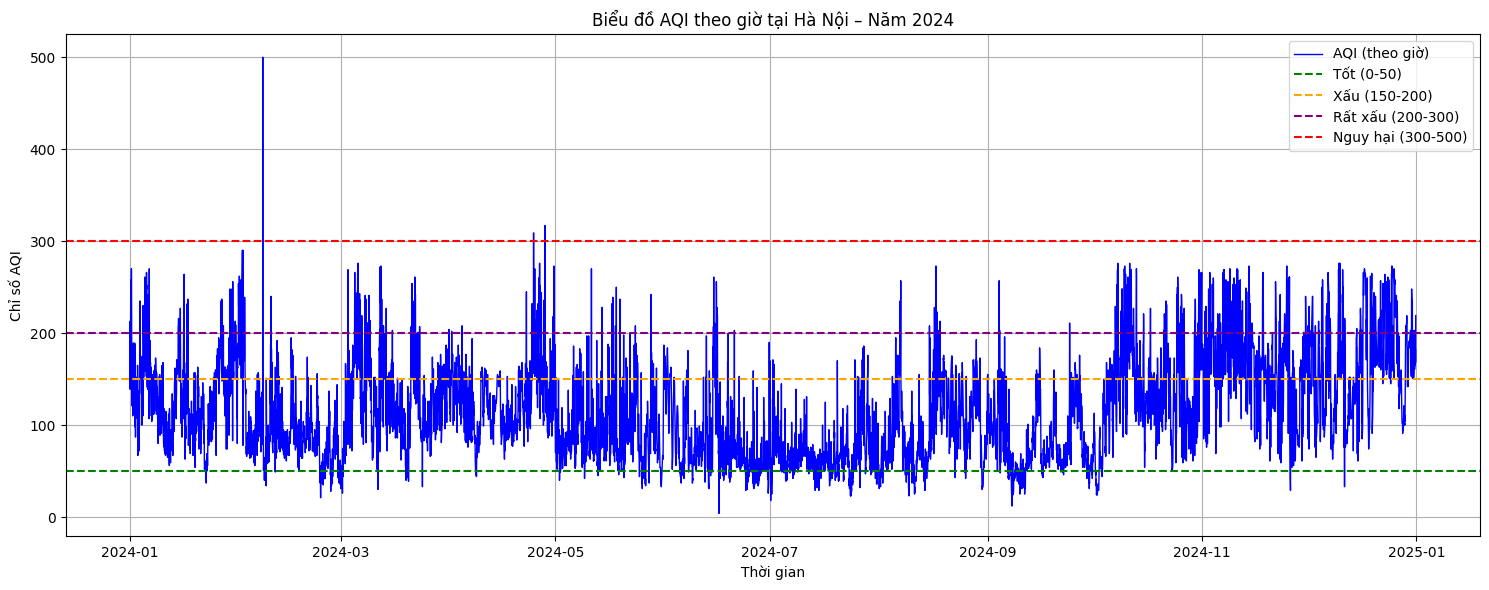

Năm 2023: AQI cao nhất = 487 vào lúc 2023-11-19 20:00:00
Năm 2024: AQI cao nhất = 500 vào lúc 2024-02-07 19:00:00


In [24]:
df['Local Time'] = pd.to_datetime(df['Local Time'])

df023 = df[df['Local Time'].dt.year == 2023]
df024 = df[df['Local Time'].dt.year == 2024]

# Biểu đồ năm 2023
plt.figure(figsize=(15,6))
plt.plot(df023['Local Time'], df023['AQI'], color='blue', linewidth=1, label='AQI (theo giờ)')
plt.title('Biểu đồ AQI theo giờ tại Hà Nội – Năm 2023')
plt.xlabel('Thời gian')
plt.ylabel('Chỉ số AQI')
plt.axhline(y=50, color='green', linestyle='--', label='Tốt (0-50)')
plt.axhline(y=150, color='orange', linestyle='--', label='Xấu (150-200)')
plt.axhline(y=200, color='purple', linestyle='--', label='Rất xấu (200-300)')
plt.axhline(y=300, color='red', linestyle='--', label='Nguy hại (300-500)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Biểu đồ năm 2024
plt.figure(figsize=(15,6))
plt.plot(df024['Local Time'], df024['AQI'], color='blue', linewidth=1, label='AQI (theo giờ)')
plt.title('Biểu đồ AQI theo giờ tại Hà Nội – Năm 2024')
plt.xlabel('Thời gian')
plt.ylabel('Chỉ số AQI')
plt.axhline(y=50, color='green', linestyle='--', label='Tốt (0-50)')
plt.axhline(y=150, color='orange', linestyle='--', label='Xấu (150-200)')
plt.axhline(y=200, color='purple', linestyle='--', label='Rất xấu (200-300)')
plt.axhline(y=300, color='red', linestyle='--', label='Nguy hại (300-500)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


max_2023 = df023.loc[df023['AQI'].idxmax()]
max_2024 = df024.loc[df024['AQI'].idxmax()]
print(f"Năm 2023: AQI cao nhất = {max_2023['AQI']} vào lúc {max_2023['Local Time']}")
print(f"Năm 2024: AQI cao nhất = {max_2024['AQI']} vào lúc {max_2024['Local Time']}")


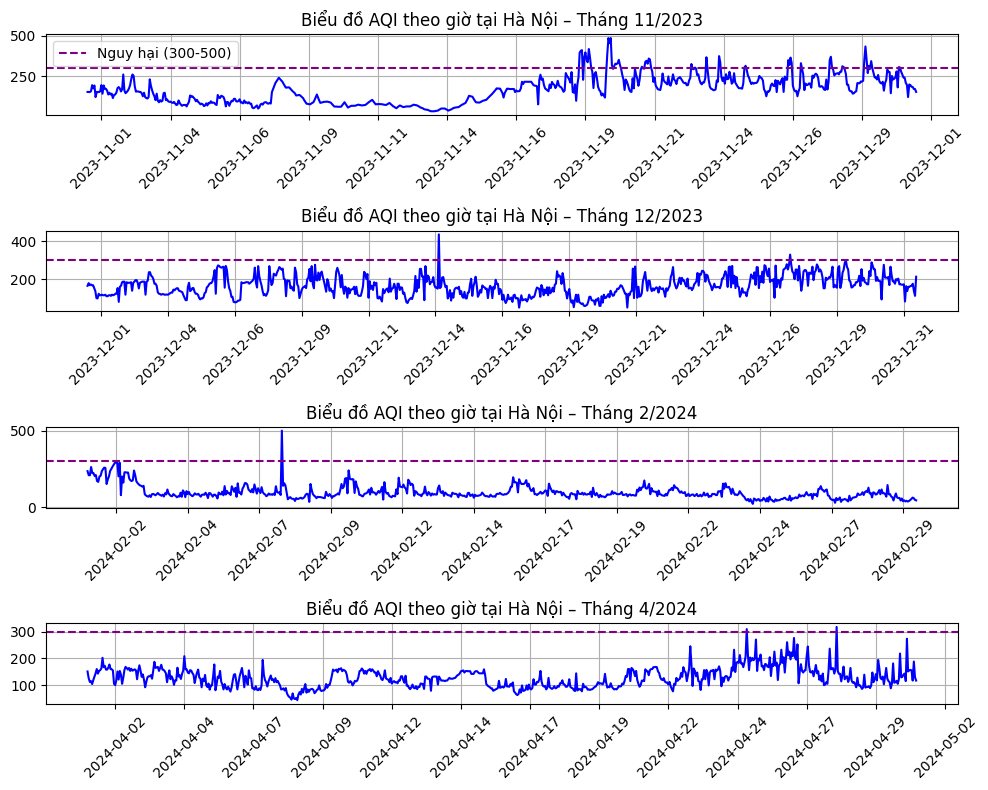

In [25]:
df.set_index('Local Time', inplace=True)
fig, axs = plt.subplots(4, 1, figsize=(10, 8))

# Vẽ biểu đồ cho từng tháng
axs[0].plot(df.loc['2023-11-01':'2023-11-30']["AQI"], color='b')
axs[0].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 11/2023')
axs[0].grid(True)
axs[0].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')
axs[0].legend()


axs[1].plot(df.loc['2023-12-01':'2023-12-31']["AQI"], color='b')
axs[1].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 12/2023')
axs[1].grid(True)
axs[1].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')


axs[2].plot(df.loc['2024-02-01':'2024-02-29']["AQI"], color='b')
axs[2].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 2/2024')
axs[2].grid(True)
axs[2].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')


axs[3].plot(df.loc['2024-04-01':'2024-04-30']["AQI"], color='b')
axs[3].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 4/2024')
axs[3].grid(True)
axs[3].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')


for ax in axs:
    ax.xaxis.set_major_locator(plt.MaxNLocator(15))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


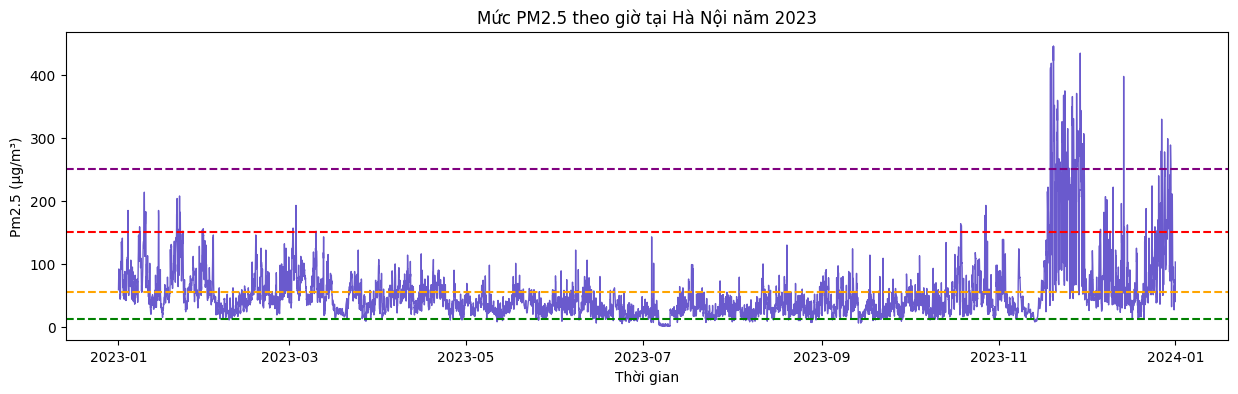

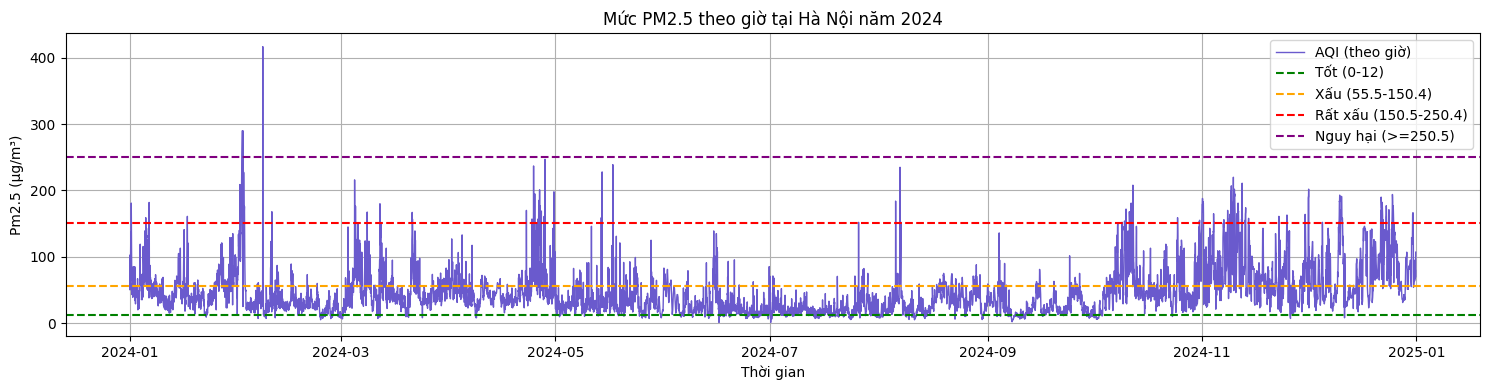

In [26]:
# Năm 2023

plt.figure(figsize=(15, 4))
plt.plot(df023['Local Time'], df023['PM25'], color='slateblue', linewidth=1, label='AQI (theo giờ)')
plt.xlabel('Thời gian')
plt.ylabel('Pm2.5 (μg/m³)')
plt.title('Mức PM2.5 theo giờ tại Hà Nội năm 2023')
plt.axhline(y=12, color='green', linestyle='--', label='Tốt (0-12)')
plt.axhline(y=55.5, color='orange', linestyle='--', label='Xấu (55.5-150.4)')
plt.axhline(y=150.5, color='red', linestyle='--', label='Rất xấu (150.5-250.4)')
plt.axhline(y=250.5, color='purple', linestyle='--', label='Nguy hại (>=250.5)')

# Năm 2024
plt.figure(figsize=(15, 4))
plt.plot(df024['Local Time'], df024['PM25'], color='slateblue', linewidth=1, label='AQI (theo giờ)')
plt.xlabel('Thời gian')
plt.ylabel('Pm2.5 (μg/m³)')
plt.title('Mức PM2.5 theo giờ tại Hà Nội năm 2024')

plt.axhline(y=12, color='green', linestyle='--', label='Tốt (0-12)')
plt.axhline(y=55.5, color='orange', linestyle='--', label='Xấu (55.5-150.4)')
plt.axhline(y=150.5, color='red', linestyle='--', label='Rất xấu (150.5-250.4)')
plt.axhline(y=250.5, color='purple', linestyle='--', label='Nguy hại (>=250.5)')


plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
df.head(2)

,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
Local Time,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,2022-12-31T17:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,59.0,62.3,87,0.0,1024,73,14.8,0.0,0.66
2023-01-01 01:00:00,2022-12-31T18:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,71.0,59.0,87,0.0,1023,75,14.6,0.0,1.00


In [28]:
df.reset_index(inplace=True)
hourly_pm25 = df.groupby(df['Local Time'].dt.hour)['PM25'].mean()
highest_hours = hourly_pm25.nlargest(5).round(2) 
print(highest_hours)

Local Time
8     56.33
20    55.92
9     55.45
21    54.53
6     54.37
Name: PM25, dtype: float64


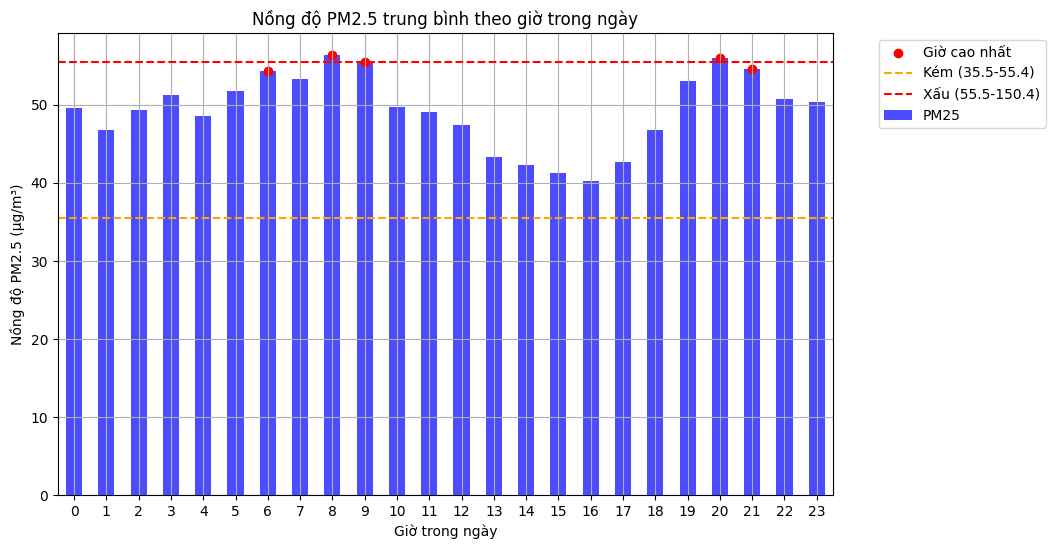

In [29]:
plt.figure(figsize=(10, 6))
hourly_pm25.plot(kind='bar', color='blue', alpha=0.7)  
plt.scatter(highest_hours.index, highest_hours.values, color='red', label='Giờ cao nhất') 
plt.title('Nồng độ PM2.5 trung bình theo giờ trong ngày')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Nồng độ PM2.5 (μg/m³)')
plt.axhline(y=35.5, color='orange', linestyle='--', label='Kém (35.5-55.4)')
plt.axhline(y=55.5, color='red', linestyle='--', label='Xấu (55.5-150.4)')


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.xticks(rotation='horizontal')

plt.show()

In [36]:
df

,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
Local Time,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,2022-12-31T17:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,59.00,62.3,87,0.0,1024,73,14.8,0.0,0.66
2023-01-01 01:00:00,2022-12-31T18:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,71.00,59.0,87,0.0,1023,75,14.6,0.0,1.00
2023-01-01 02:00:00,2022-12-31T19:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,179,203.7,6.0,54.0,96.3,77.00,58.0,83,0.0,1023,79,14.3,0.0,1.00
2023-01-01 03:00:00,2022-12-31T20:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,199,201.3,6.0,52.0,115.0,92.00,57.0,79,0.0,1023,82,14.1,0.0,1.00
2023-01-01 04:00:00,2022-12-31T21:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,199.0,6.0,50.0,80.0,64.00,56.0,75,0.0,1022,86,13.8,0.0,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 15:00:00,2024-12-31T08:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,173,605.0,15.0,27.0,100.0,73.00,26.0,37,0.0,1018,82,16.8,0.0,2.00
2024-12-31 16:00:00,2024-12-31T09:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,165,806.0,8.0,15.1,94.0,67.00,26.0,1,0.0,1018,86,16.0,0.0,2.00
2024-12-31 17:00:00,2024-12-31T10:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,183,1310.0,10.3,10.8,108.0,80.33,28.0,0,0.0,1018,90,15.2,0.0,2.00


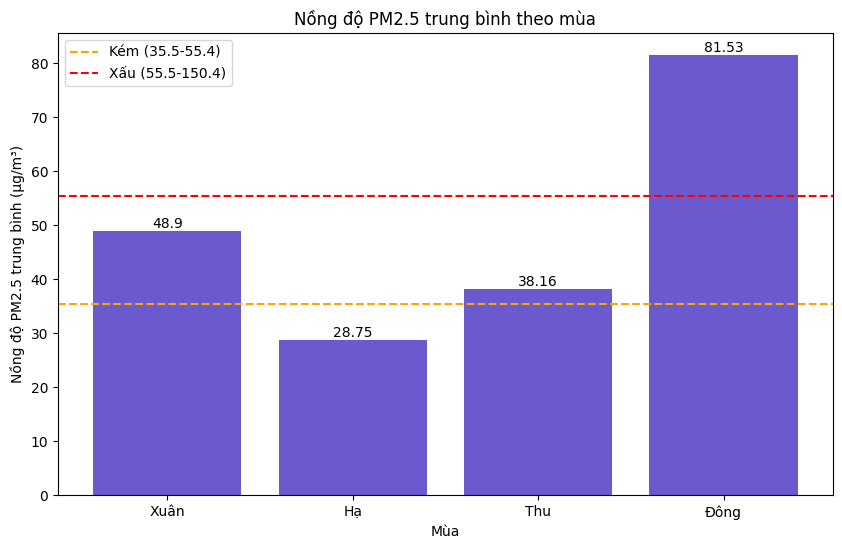

In [34]:

seasons = {
    'Xuân': [2, 3, 4],
    'Hạ': [5, 6, 7],
    'Thu': [8, 9, 10],
    'Đông': [11, 12, 1]
}


seasonal_pm25 = {}
for season, months in seasons.items():
    seasonal_pm25[season] = df.loc[df.index.month.isin(months), 'PM25'].mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(seasonal_pm25.keys(), seasonal_pm25.values(), color='slateblue')
plt.title('Nồng độ PM2.5 trung bình theo mùa')
plt.xlabel('Mùa')
plt.ylabel('Nồng độ PM2.5 trung bình (μg/m³)')
plt.axhline(y=35.5, color='orange', linestyle='--', label='Kém (35.5-55.4)')
plt.axhline(y=55.5, color='red', linestyle='--', label='Xấu (55.5-150.4)')
plt.legend()


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2),
             ha='center', va='bottom')

plt.show()

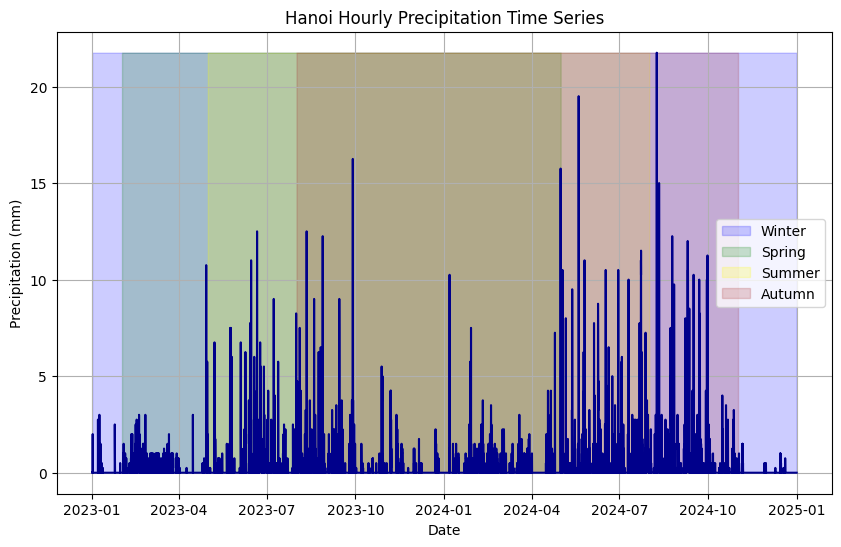

Annual Precipitation: 5049.5 mm


In [35]:

plt.figure(figsize=(10, 6))

winter_months = [11, 12, 1]
spring_months = [2, 3, 4]
summer_months = [5, 6, 7]
autumn_months = [8, 9, 10]


plt.plot(df.index, df['Precipitation'], color='darkblue')


plt.fill_between(df.index[df.index.month.isin(winter_months)], df['Precipitation'].min(), df['Precipitation'].max(), color='blue', alpha=0.2, label='Winter')
plt.fill_between(df.index[df.index.month.isin(spring_months)], df['Precipitation'].min(), df['Precipitation'].max(), color='green', alpha=0.2, label='Spring')
plt.fill_between(df.index[df.index.month.isin(summer_months)], df['Precipitation'].min(), df['Precipitation'].max(), color='yellow', alpha=0.2, label='Summer')
plt.fill_between(df.index[df.index.month.isin(autumn_months)], df['Precipitation'].min(), df['Precipitation'].max(), color='brown', alpha=0.2, label='Autumn')

plt.title('Hanoi Hourly Precipitation Time Series')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')

plt.legend()
plt.grid(True)
plt.show()

annual_total_precipitation = df['Precipitation'].sum()

print("Annual Precipitation:", annual_total_precipitation, "mm")